In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visuals
sns.set(style="whitegrid")

In [28]:
df = pd.read_csv('../dataset/processed_data/cleaned_data.csv')

df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,0,1.62,64.0,3,0,2.0,3.0,0,0,2.0,1,0.0,1.0,2,3,1
1,21.0,0,1.52,56.0,2,0,3.0,3.0,1,1,3.0,1,3.0,0.0,2,3,1
2,23.0,1,1.80,77.0,1,0,2.0,3.0,0,0,2.0,1,2.0,1.0,2,3,1
3,27.0,1,1.80,87.0,1,0,3.0,3.0,0,0,2.0,0,2.0,0.0,2,4,5
4,22.0,1,1.78,89.8,2,0,2.0,1.0,0,0,2.0,0,0.0,0.0,2,3,6


In [29]:
obesity_map = {
    0: "Insufficient Weight",
    1: "Normal Weight",
    2: "Overweight Level I",
    3: "Overweight Level II",
    4: "Obesity Type I",
    5: "Obesity Type II",
    6: "Obesity Type III"
}

df['Obesity_Label'] = df['NObeyesdad'].map(obesity_map)


In [30]:
df[['NObeyesdad', 'Obesity_Label']].head()

,NObeyesdad,Obesity_Label
0,1,Normal Weight
1,1,Normal Weight
2,1,Normal Weight
3,5,Obesity Type II
4,6,Obesity Type III


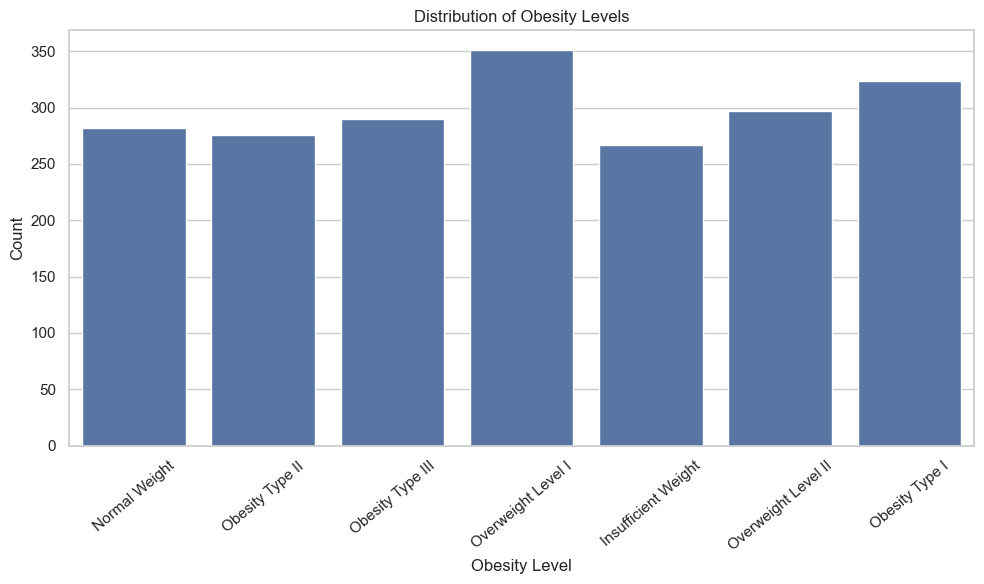

In [31]:
plt.figure(figsize=(10,6))

sns.countplot(x='Obesity_Label', data=df)

plt.title("Distribution of Obesity Levels")
plt.xlabel("Obesity Level")
plt.ylabel("Count")

plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

In [32]:
# Convert FAF to readable categories
faf_map = {
    0: "No Activity",
    1: "Low",
    2: "Moderate",
    3: "High"
}

df['FAF_Label'] = df['FAF'].map(faf_map)

In [33]:
def simplify_obesity(x):
    if x in ["Insufficient Weight", "Normal Weight"]:
        return "Normal"
    elif "Overweight" in x:
        return "Overweight"
    else:
        return "Obese"

df['Obesity_Simple'] = df['Obesity_Label'].apply(simplify_obesity)

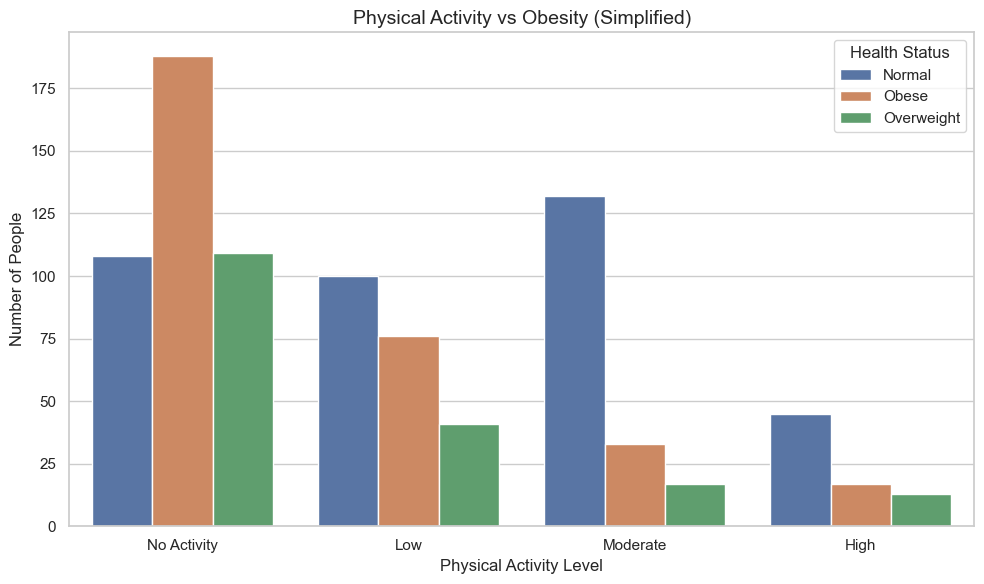

In [34]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='FAF_Label',
    hue='Obesity_Simple',
    data=df,
    order=["No Activity", "Low", "Moderate", "High"]
)

plt.title("Physical Activity vs Obesity (Simplified)", fontsize=14)
plt.xlabel("Physical Activity Level")
plt.ylabel("Number of People")

plt.legend(title="Health Status")
plt.tight_layout()

plt.show()

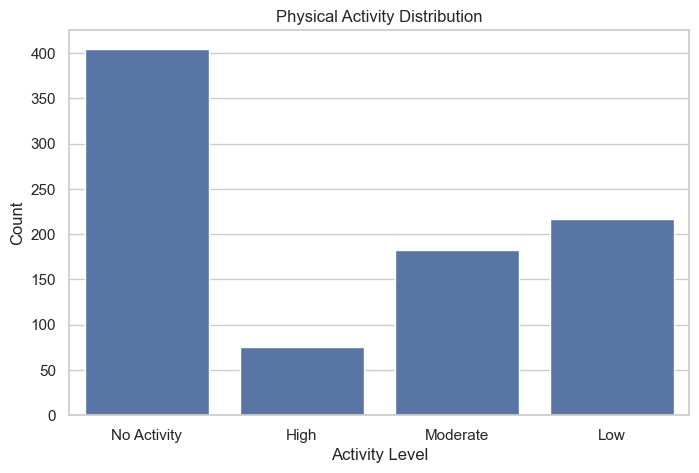

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(x='FAF_Label', data=df)

plt.title("Physical Activity Distribution")
plt.xlabel("Activity Level")
plt.ylabel("Count")

plt.show()

In [36]:

# Obesity simplified
def simplify_obesity(x):
    if x in ["Insufficient Weight", "Normal Weight"]:
        return "Normal"
    elif "Overweight" in x:
        return "Overweight"
    else:
        return "Obese"

df['Obesity_Simple'] = df['Obesity_Label'].apply(simplify_obesity)

# FAF labels
faf_map = {0: "No Activity", 1: "Low", 2: "Moderate", 3: "High"}
df['FAF_Label'] = df['FAF'].map(faf_map)

# CH2O labels (water intake)
water_map = {1: "Low", 2: "Medium", 3: "High"}
df['CH2O_Label'] = df['CH2O'].round().map(water_map)

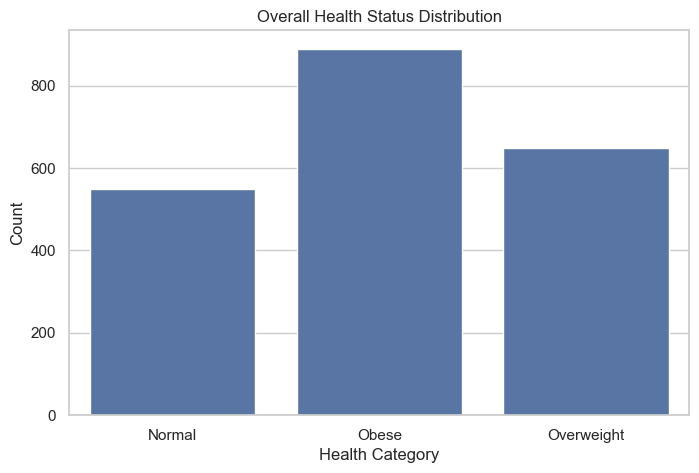

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(x='Obesity_Simple', data=df)

plt.title("Overall Health Status Distribution")
plt.xlabel("Health Category")
plt.ylabel("Count")

plt.show()

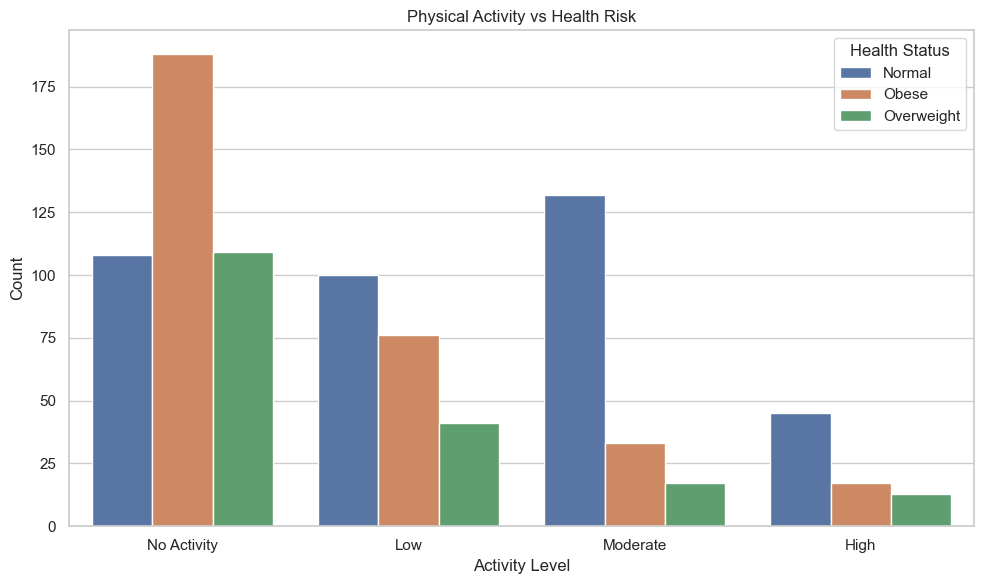

In [38]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='FAF_Label',
    hue='Obesity_Simple',
    data=df,
    order=["No Activity", "Low", "Moderate", "High"]
)

plt.title("Physical Activity vs Health Risk")
plt.xlabel("Activity Level")
plt.ylabel("Count")

plt.legend(title="Health Status")
plt.tight_layout()

plt.show()

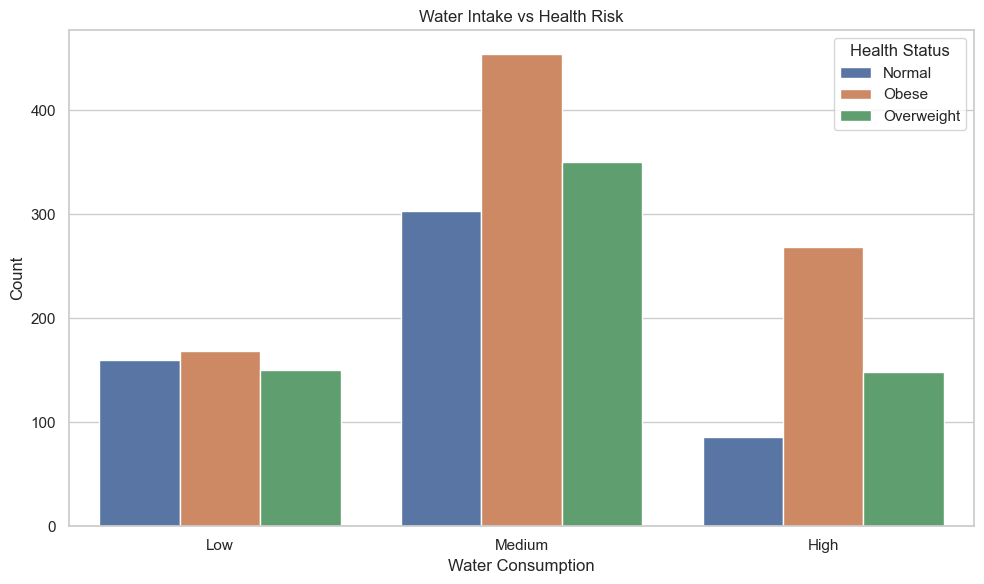

In [39]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='CH2O_Label',
    hue='Obesity_Simple',
    data=df,
    order=["Low", "Medium", "High"]
)

plt.title("Water Intake vs Health Risk")
plt.xlabel("Water Consumption")
plt.ylabel("Count")

plt.legend(title="Health Status")
plt.tight_layout()

plt.show()

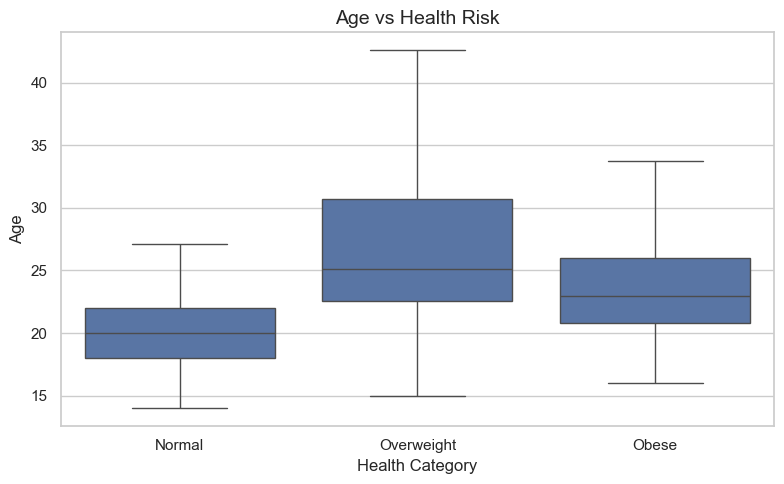

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ensure readable labels exist
obesity_map = {
    0: "Insufficient Weight",
    1: "Normal Weight",
    2: "Overweight Level I",
    3: "Overweight Level II",
    4: "Obesity Type I",
    5: "Obesity Type II",
    6: "Obesity Type III"
}

df['Obesity_Label'] = df['NObeyesdad'].map(obesity_map)

# Step 2: Simplify categories
def simplify_obesity(x):
    if x in ["Insufficient Weight", "Normal Weight"]:
        return "Normal"
    elif "Overweight" in x:
        return "Overweight"
    else:
        return "Obese"

df['Obesity_Simple'] = df['Obesity_Label'].apply(simplify_obesity)

# Step 3: Remove any missing values
df = df.dropna(subset=['Obesity_Simple', 'Age'])

# Step 4: Define order
order = ["Normal", "Overweight", "Obese"]

# Step 5: Plot clean graph
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Obesity_Simple',
    y='Age',
    data=df,
    order=order,
    showfliers=False
)

plt.title("Age vs Health Risk", fontsize=14)
plt.xlabel("Health Category")
plt.ylabel("Age")

plt.tight_layout()
plt.show()